# Mask & Crop

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on masking and croping a raster object.

The following librairies will be considered :
- `rasterio`
- `rioxarray`
- `odc-geo`
- `geoutils`

In [ ]:
import numpy as np

import geopandas as gpd

import rasterio
import rasterio.mask
from rasterio.plot import show

import rioxarray

import odc.geo.xr
from odc.geo.xr import mask
from odc.geo.xr import crop
from odc.geo.geom import Geometry

import geoutils as gu

import matplotlib.pyplot as plt

from shapely.geometry import mapping

In [2]:
#path to the raster object
raster_path = "../data/rasters/105005005BDEA700-visual.tif"

In [3]:
#path to the vector object
vector_path = "../data/vectors/extent.shp"

## Masking (with a vector)

Masking with a vector is a feature available in `rasterio`, `rioxarray` and `odc-geo` librairies, but not (yet) in `geoutils`.

A vector mask allows to isolate a specific area of interest according to the shape of the mask.

In this example we will work with a polygon (.shp) focusing on a small part of the raster.

In [4]:
gdf = gpd.read_file(vector_path)

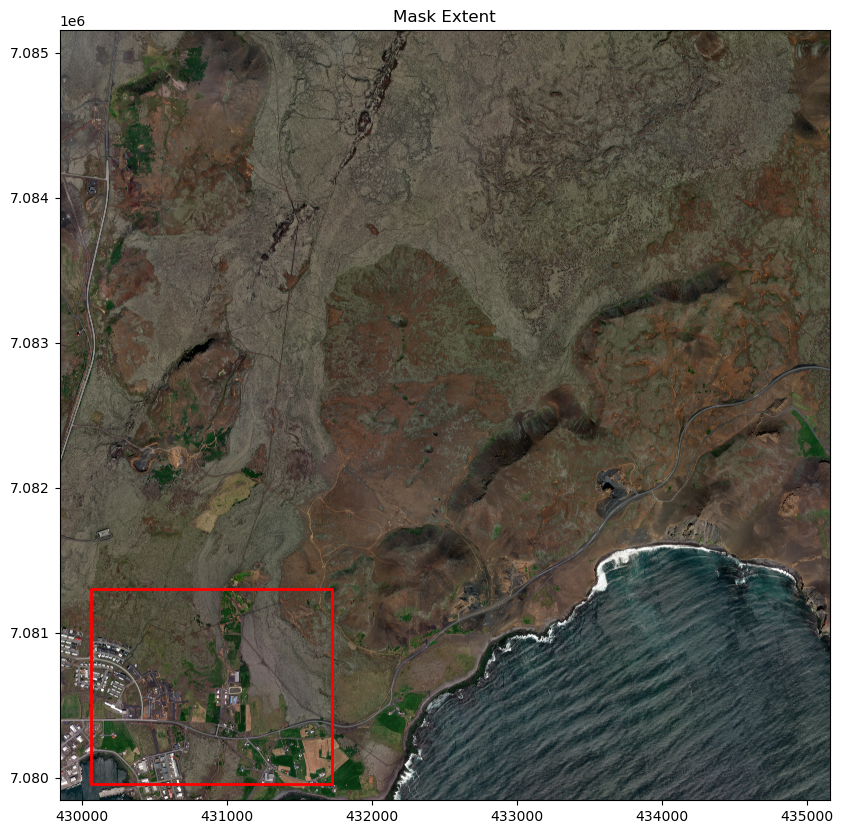

In [34]:
with rasterio.open(raster_path) as src:
    fig, ax = plt.subplots(figsize=(10, 10))

    show(src, ax=ax)

    gdf.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
    
    plt.title("Mask Extent")
    plt.show()

### • rasterio

First, we can create our vector shape to be used as a mask using [`.mapping`](https://shapely.readthedocs.io/en/stable/manual.html#shapely.geometry.mapping) from the `shapely` library.

It will return geojson-like object corresponding to our polygon and its associated coordinates:

In [5]:
geoms = [mapping(geom) for geom in gdf.geometry]

In [52]:
geoms

[{'type': 'Polygon',
  'coordinates': (((430060.6926998461, 7079958.663299363),
    (430060.6926998461, 7081304.62049697),
    (431721.66115646675, 7081304.62049697),
    (431721.66115646675, 7079958.663299363),
    (430060.6926998461, 7079958.663299363)),)}]

With `rasterio`, we can then use the [`.mask()` function](https://rasterio.readthedocs.io/en/latest/api/rasterio.mask.html):

This function will create a mask on our extent and set to nodata pixels outside the input shape.

As arguments, we pass the opened raster, our mask (vector) previously created and specify `crop=False` to not crop to the extent of the shape.

In [49]:
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, geoms, crop=False)

The output contains two elements: an array with the data of the raster, and the affine transform matrix associated.

We can plot the result :

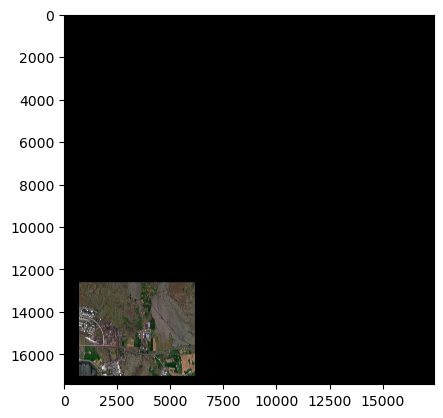

<Axes: >

In [50]:
show(out_image)

### • rioxarray

In rioxarray, we can use the [`.clip()` function](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.clip):

As arguments, we pass the geometries of the extent previously created, and once again we specify `drop=False` (as `crop=False` for rasterio) to not crop to the extent of the shape.

In [6]:
da_rxr = rioxarray.open_rasterio(raster_path)

da_clipped = da_rxr.rio.clip(geoms, drop=False)

c:\Users\cbernaert\AppData\Local\anaconda3\envs\open_source_rasters_comparison\Lib\site-packages\xarray\core\duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


We can plot the result:

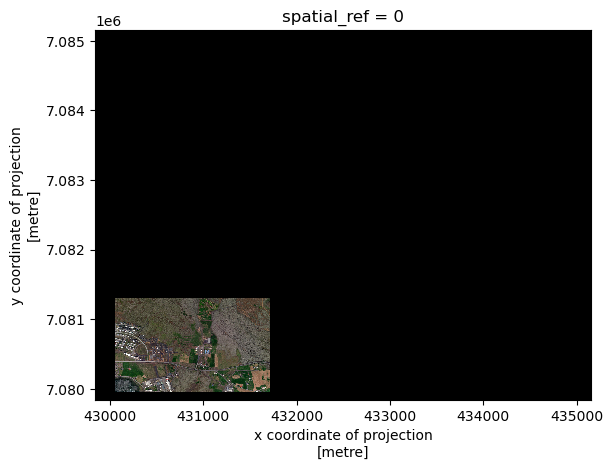

In [7]:
da_clipped.plot.imshow()
plt.show()

### • odc-geo

In `odc-geo`, we will use the [`.mask()` function](https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.mask.html):

In [53]:
ds_odcgeo = rioxarray.open_rasterio(raster_path)

First, we need to create an object `odc.geo.geom.Geometry` to be used as a mask, and also specify the CRS:

In [13]:
g = Geometry(gdf.geometry.iloc[0], crs="EPSG:32627")

After that, we can use our vector with the `.mask()` function.

It will set all pixels outside the extent to NaN.

We apply the function to our input raster, and specify as arguments our Geometry object previously created and `invert=False`, to set all the pixels outside the extent as nodata and not the opposite:

In [66]:
odcgeo_clipped = ds_odcgeo.odc.mask(poly=g, invert=False)

We can finally plot the result:

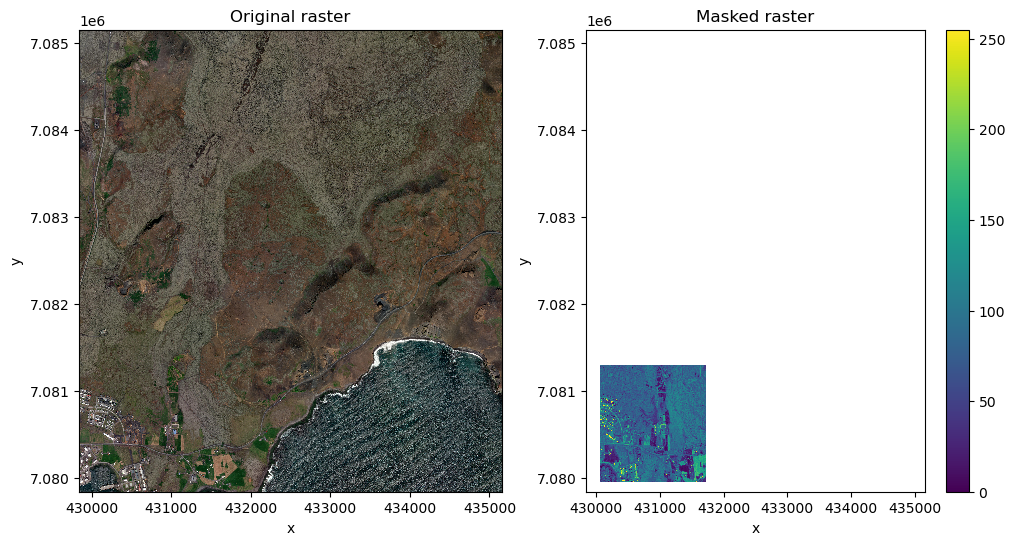

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ds_odcgeo.plot.imshow(ax=ax[0])
ax[0].set_title("Original raster")

odcgeo_clipped.sel(band=1).plot.imshow(ax=ax[1])
ax[1].set_title("Masked raster")

plt.show()

### • geoutils

In geoutils, this feature has an [opened issue](https://github.com/GlacioHack/geoutils/issues/583).

## Crop

Cropping feature is available in `rasterio`, `rioxarray`, `odc-geo` and `geoutils`.

This method is used to delete all pixels outside of a specified area (and not to set them as nodata, like masking).

### • rasterio

To use this feature in rasterio, we can use again the `.mask()` function.

This time, we will pass the argument `crop=True` so we do not keep the pixels outside our extent.

In [8]:
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)

If we plot the image, borders have been erased :

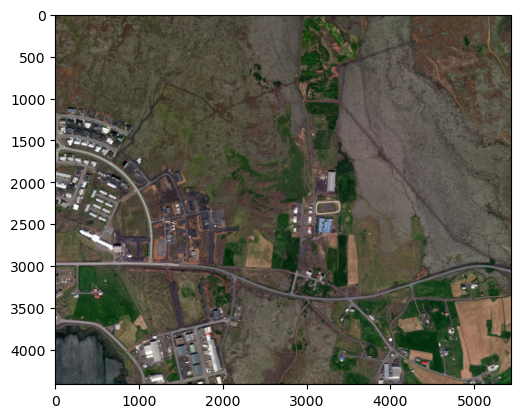

<Axes: >

In [9]:
show(out_image)

### • rioxarray

In rioxarray, we can use the [`.clip_box()` function](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.clip_box):

In [17]:
da_rxr = rioxarray.open_rasterio(raster_path)

To use this function, we first need to get the bounds of our polygon:

In [46]:
minx, miny, maxx, maxy = gdf.geometry.total_bounds

Then, we can apply the `clip_box()` function.

We need to specify the bounds of the box we want to use:

In [48]:
rxr_cropped = da_rxr.rio.clip_box(minx=minx,miny=miny,maxx=maxx,maxy=maxy)

Finally, we can plot the image:

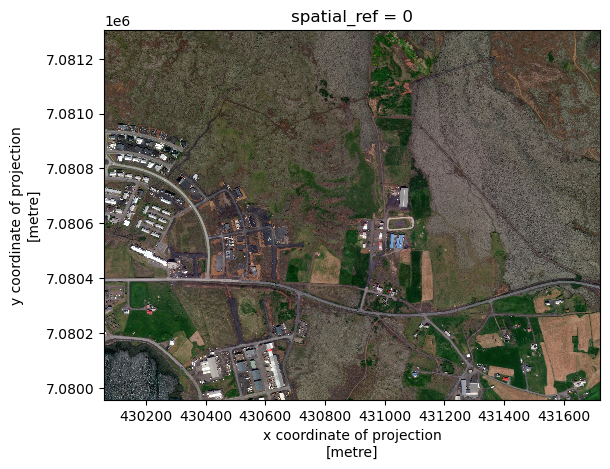

In [49]:
rxr_cropped.plot.imshow()

### • odc-geo

For odc-geo, we will use the [`.crop()` function](https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.crop.html#odc.geo.xr.crop):

In [21]:
ds_odcgeo = rioxarray.open_rasterio(raster_path)

As an argument, we pass the Geometry object previously created :

In [72]:
odcgeo_cropped = ds_odcgeo.odc.crop(g)

Finally, we can plot the image :

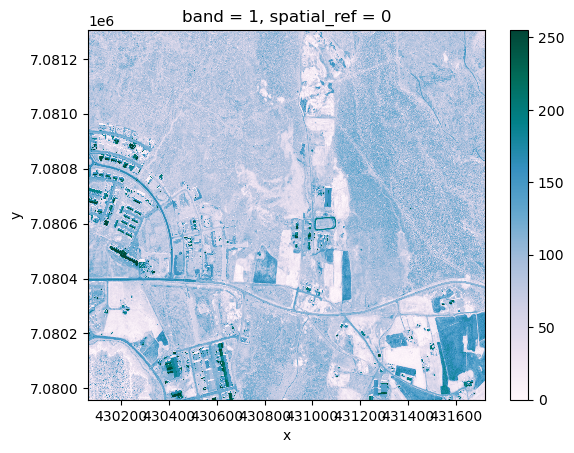

In [76]:
odcgeo_cropped.sel(band=1).plot(cmap="PuBuGn")
plt.show()

### • geoutils

For geoutils, we will directly use the [`.crop()` function](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.crop.html#geoutils.Raster.crop):

In [23]:
gu_rast = gu.Raster(raster_path)

gu_vect = gu.Vector(vector_path)

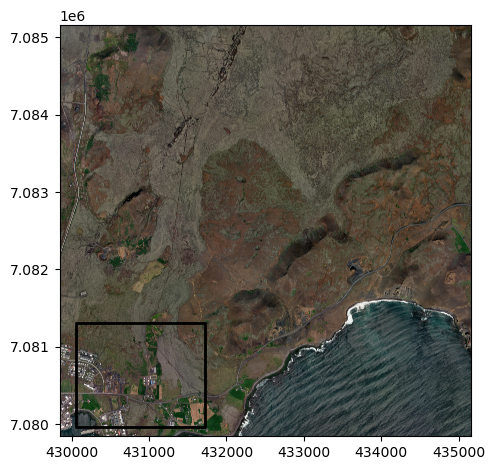

In [25]:
gu_rast.plot()
gu_vect.plot(fc="none", ec="k", lw=2)

Then, we can use the `.crop `function, we just have to pass the extent vector as an argument:

In [26]:
gu_cropped = gu_rast.crop(gu_vect)

And finally plot the newly cropped raster:

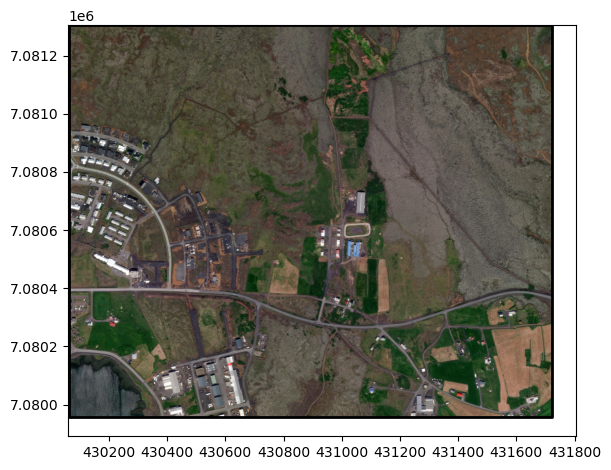

In [27]:
gu_cropped.plot(ax="new")
gu_vect.plot(fc="none", ec="k", lw=2)